# A/B Experiment Analysis — Default UI vs Any Non-default UI

## Scope
This notebook evaluates the **overall treatment effect** of **any non-default UI exposure**
relative to the **global default UI**.

- **Control**: `visit_group == "default"`
- **Treatment (any non-default)**: `visit_group != "default"`

Variant-level analysis and multiple testing (FDR) are handled in the dedicated
variant notebook (03).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from math import sqrt
from scipy.stats import norm, chisquare

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)


## 1. Load Data (event-level logs)

We start from event-level logs and construct a session-level dataset aligned with
the experiment unit before any inference.


In [2]:
PATH = "../data/visit.csv"  

df = pd.read_csv(
    PATH,
    nrows=200_000,         
    sep=None,
    engine="python",
    encoding="latin1",
    on_bad_lines="skip",
)



# Basic shape and schema
print("raw df shape:", df.shape)
df.head()


raw df shape: (200000, 14)


,session_token,session_fingerprint,session_userToken,session_siteId,session_userId,visit_url,visit_type,visit_group,visit_category,visit_action,visit_name,visit_time,visit_visitKey,visit_groupSource
0,2150592,f8743a40576f03f5,NaN,6,ded242a9-155b-4705-b78e-902ac35b1fa8,https://4fstore.lv/zenu-gluds-polo-krekls-4fjs...,event,230401_230612_1686725101__3_default,ProductPage,selectSize,152,2023-07-09 13:37:47,event-ProductPage-selectSize-152-zenu-gluds,default
1,1507298,7f6ae472f1bdefad,NaN,6,NaN,https://4fstore.lv/zenu-pilsetas-virsjaka-4fjs...,product,default,NaN,NaN,NaN,2023-05-20 11:30:12,product-zenu-pilsetas,default
2,1533978,416e82324fcf473b,NaN,6,0a6b0cf5-4c84-418b-a037-d16451b287e8,https://4fstore.lv/viriesu-velosorti-ar-gela-i...,product,default,NaN,NaN,NaN,2023-05-27 19:52:43,product-viriesu-velosorti,default
3,1443657,b0522e87b07575da,NaN,6,NaN,https://4fstore.lv/?click_id=9gyZ1YxXfAZe1z7,other,default,NaN,NaN,NaN,2023-05-02 20:01:07,other,default
4,1373543,368ad8fa76f49c1d,NaN,6,NaN,https://4fstore.lv/sieviesu-neatpogajama-sport...,product,default,NaN,NaN,NaN,2023-04-12 17:54:58,product-sieviesu-neatpogajama,default


## 2. Minimal Sanity Checks

We verify required columns exist and parse timestamps.


In [3]:
required_cols = ["session_token", "session_userId", "visit_group", "visit_action", "visit_time"]
missing_cols = [c for c in required_cols if c not in df.columns]
missing_cols


[]

In [4]:
df["visit_time"] = pd.to_datetime(df["visit_time"], errors="coerce")
df["visit_time"].isna().mean(), df["visit_time"].min(), df["visit_time"].max()


(np.float64(0.0),
 Timestamp('2023-04-01 00:04:12'),
 Timestamp('2023-07-14 23:52:42'))

## 3. Build Session-level Dataset

### High-intent conversion definition
A session is labeled as `converted_hi = 1` if it contains at least one action in `HIGH_INTENT_ACTIONS`.

> This is a **behavioral proxy** for conversion intent. The goal is to compare intent rates
across UI exposure groups in the logs


In [5]:
DEFAULT_GROUP = "default"
HIGH_INTENT_ACTIONS = {"selectSize", "miniCart"}  # confirmed as high-intent actions

def safe_mode(x):
    m = x.mode()
    return m.iloc[0] if len(m) else np.nan

session = (
    df.groupby("session_token")
      .agg(
          user_id=("session_userId", safe_mode),
          ui_group=("visit_group", safe_mode),
          session_start=("visit_time", "min"),
          session_end=("visit_time", "max"),
          n_events=("visit_action", "size"),
          n_unique_actions=("visit_action", "nunique"),
      )
)

session["session_duration_sec"] = (
    session["session_end"] - session["session_start"]
).dt.total_seconds()

converted_hi = (
    df.assign(is_hi=df["visit_action"].isin(HIGH_INTENT_ACTIONS))
      .groupby("session_token")["is_hi"]
      .any()
      .astype(int)
      .rename("converted_hi")
)

session = session.join(converted_hi, how="left")
session["converted_hi"] = session["converted_hi"].fillna(0).astype(int)

# Exposure definition
session["is_non_default"] = (session["ui_group"] != DEFAULT_GROUP).astype(int)

# Remove obvious invalid label if present (your data has "false" occasionally)
session = session[session["ui_group"].astype(str).str.lower() != "false"].copy()

session.head(), session.shape


(              user_id ui_group       session_start         session_end  n_events  n_unique_actions  \
 session_token                                                                                        
 1325679           NaN  default 2023-04-01 00:04:12 2023-04-01 00:04:12         1                 0   
 1325691           NaN  default 2023-04-01 00:25:33 2023-04-01 00:25:33         1                 0   
 1325701           NaN  default 2023-04-01 00:49:42 2023-04-01 00:49:42         1                 0   
 1325705           NaN  default 2023-04-01 00:54:29 2023-04-01 00:54:29         1                 0   
 1325706           NaN  default 2023-04-01 01:02:29 2023-04-01 01:02:29         1                 0   
 
                session_duration_sec  converted_hi  is_non_default  
 session_token                                                      
 1325679                         0.0             0               0  
 1325691                         0.0             0               0  
 

In [21]:
# save session-level dataset for downstream analysis
session.to_parquet("../data/session_level.parquet")


## 4. Exposure Summary

Since this is observational, it is crucial to understand the exposure imbalance.


In [6]:
counts = session["is_non_default"].value_counts().sort_index()
summary = pd.DataFrame({"count": counts, "proportion": counts / counts.sum()})
summary.rename(index={0: "baseline_default", 1: "exposed_non_default"})


,count,proportion
is_non_default,,
baseline_default,91866,0.916077
exposed_non_default,8416,0.083923


In [7]:
# optional: see top UI groups by session count
session["ui_group"].value_counts().head(20)


ui_group
default                                                             91866
230401_230612_1686725101__lottery_default                            1609
230401_230612_1686725101__lottery                                    1527
230401_230612_1686725101__2                                           968
230401_230612_1686725101__2_default                                   886
8783cca2582243602a52eee552472f0856f35ff55c49ca4d97cc61f5d379b740      635
230401_230612_1686725101__4                                           496
230401_230612_1686725101__4_default                                   437
230401_230612_1686725101__3                                           436
230401_230612_1686725101__3_default                                   413
f13213565627e05fcf069a678d30f13ba72c73297b5ca0ec31c679ba29bdeab1      291
230401_230612_1686725101__1                                           285
230401_230612_1686725101__1_default                                   269
4aaa1ff93ba3b7da9e7a22e0874d6

## 5. Effect Estimation (Associational)

We report:
- conversion rates in baseline vs exposed
- absolute difference (pp)
- 95% CI (unpooled)
- two-proportion z-test p-value (reported descriptively)

> Note: p-values here do not establish causality; they describe whether differences
are large relative to sampling variability.


In [8]:
def two_prop_ci_and_z(x1, n1, x0, n0, alpha=0.05):
    """
    Unpooled CI for difference in proportions + pooled z-test p-value (descriptive).
    """
    p1 = x1 / n1
    p0 = x0 / n0
    diff = p1 - p0

    # CI (unpooled)
    se_ci = sqrt(p1*(1-p1)/n1 + p0*(1-p0)/n0)
    zcrit = norm.ppf(1 - alpha/2)
    ci_low, ci_high = diff - zcrit*se_ci, diff + zcrit*se_ci

    # z-test (pooled, descriptive)
    p_pool = (x1 + x0) / (n1 + n0)
    se_pool = sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n0))
    z = diff / se_pool if se_pool > 0 else np.nan
    pval = 2 * (1 - norm.cdf(abs(z))) if np.isfinite(z) else np.nan

    return p1, p0, diff, (ci_low, ci_high), z, pval


def effect_table(df_sess, outcome="converted_hi", exposure="is_non_default"):
    g = df_sess.groupby(exposure)[outcome].agg(["sum", "count"]).rename(index={0:"baseline",1:"exposed"})
    x0, n0 = int(g.loc[0, "sum"]), int(g.loc[0, "count"])
    x1, n1 = int(g.loc[1, "sum"]), int(g.loc[1, "count"])

    p1, p0, diff, (lo, hi), z, pval = two_prop_ci_and_z(x1, n1, x0, n0)

    out = pd.DataFrame([{
        "metric": outcome,
        "n_baseline": n0,
        "n_exposed": n1,
        "rate_baseline": p0,
        "rate_exposed": p1,
        "abs_lift_pp": diff * 100,
        "ci95_low_pp": lo * 100,
        "ci95_high_pp": hi * 100,
        "z_stat": z,
        "p_value_descriptive": pval,
    }])
    return out


## 6. Primary Result — High-intent Conversion

This is the main metric used to compare intent rates across UI exposure groups.


In [14]:
def effect_table(df_sess, outcome="converted_hi", exposure="is_non_default"):
    g = df_sess.groupby(exposure)[outcome].agg(["sum", "count"]).sort_index()

    x0, n0 = int(g.loc[0, "sum"]), int(g.loc[0, "count"])
    x1, n1 = int(g.loc[1, "sum"]), int(g.loc[1, "count"])

    p1, p0, diff, (lo, hi), z, pval = two_prop_ci_and_z(x1, n1, x0, n0)

    out = pd.DataFrame([{
        "metric": outcome,
        "baseline_group": "default (global)",
        "exposed_group": "non-default (any)",
        "n_baseline": n0,
        "n_exposed": n1,
        "rate_baseline": p0,
        "rate_exposed": p1,
        "abs_lift_pp": diff * 100,
        "ci95_low_pp": lo * 100,
        "ci95_high_pp": hi * 100,
        "z_stat": z,
        "p_value_descriptive": pval,
    }])

    return out


In [15]:
primary = effect_table(session, outcome="converted_hi")
primary

,metric,baseline_group,exposed_group,n_baseline,n_exposed,rate_baseline,rate_exposed,abs_lift_pp,ci95_low_pp,ci95_high_pp,z_stat,p_value_descriptive
0,converted_hi,default (global),non-default (any),91866,8416,0.045577,0.078422,3.28448,2.694502,3.874457,13.446772,0.0


## 7. Covariate Balance Checks (Observational Validity)

Because assignment is not guaranteed to be randomized, we check whether baseline vs exposed
sessions differ systematically in engagement proxies.

Large differences would suggest targeting/selection effects and call for more cautious interpretation.


In [16]:
balance = (
    session.groupby("is_non_default")[["n_events", "n_unique_actions", "session_duration_sec"]]
           .agg(["mean", "median"])
)

balance.rename(index={0: "baseline_default", 1: "exposed_non_default"})


n_events        n_unique_actions        session_duration_sec       
                         mean median             mean median                 mean median
is_non_default                                                                          
baseline_default     1.945268    1.0         0.137472    0.0           197.747883    0.0
exposed_non_default  2.499762    2.0         0.250000    0.0           379.209363    1.0

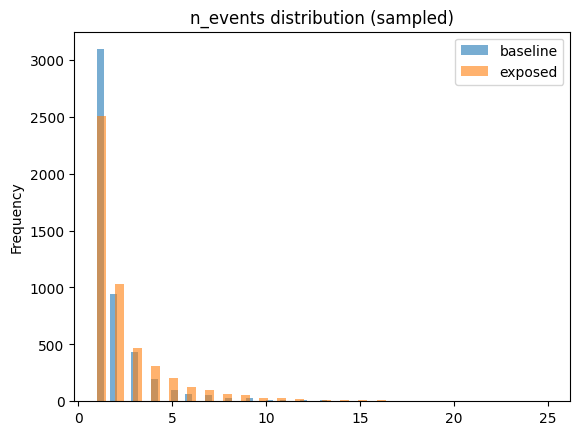

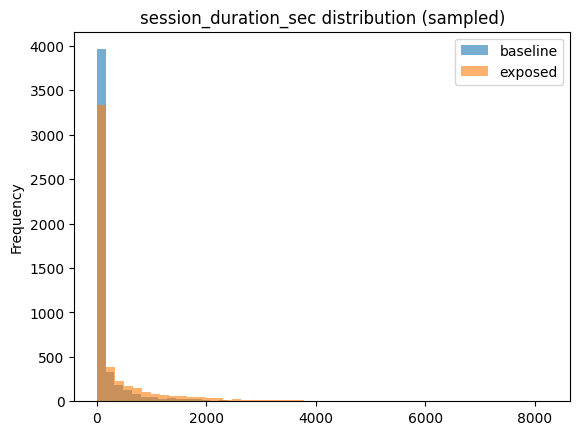

In [17]:
# Sampled histograms for a quick visual balance check
def plot_hist(col, bins=50, sample_n=5000):
    plt.figure()
    a = session[session["is_non_default"]==0][col].dropna()
    b = session[session["is_non_default"]==1][col].dropna()
    a = a.sample(min(sample_n, len(a)), random_state=0) if len(a) > 0 else a
    b = b.sample(min(sample_n, len(b)), random_state=0) if len(b) > 0 else b

    a.plot(kind="hist", bins=bins, alpha=0.6, label="baseline")
    b.plot(kind="hist", bins=bins, alpha=0.6, label="exposed")
    plt.legend()
    plt.title(f"{col} distribution (sampled)")
    plt.show()

plot_hist("n_events")
plot_hist("session_duration_sec")


## 8. Robustness / Sensitivity Analyses

We evaluate whether the observed UI–conversion association remains stable under reasonable
filters that reduce the influence of extreme engagement outliers.

This helps assess whether results are driven primarily by heavy-tail behavior.


In [18]:
def run_sensitivity(session_df):
    configs = [
        ("all_sessions", session_df),
        ("duration_le_30min", session_df[session_df["session_duration_sec"] <= 1800]),
        ("events_le_50", session_df[session_df["n_events"] <= 50]),
        ("events_between_2_50", session_df[(session_df["n_events"] >= 2) & (session_df["n_events"] <= 50)]),
    ]

    rows = []
    for name, sdf in configs:
        r = effect_table(sdf, outcome="converted_hi")
        r.insert(0, "filter", name)
        rows.append(r)

    return pd.concat(rows, ignore_index=True)

sens = run_sensitivity(session)
sens


,filter,metric,baseline_group,exposed_group,n_baseline,n_exposed,rate_baseline,rate_exposed,abs_lift_pp,ci95_low_pp,ci95_high_pp,z_stat,p_value_descriptive
0,all_sessions,converted_hi,default (global),non-default (any),91866,8416,0.045577,0.078422,3.284480,2.694502,3.874457,13.446772,0.000000e+00
1,duration_le_30min,converted_hi,default (global),non-default (any),89475,7912,0.039486,0.065976,2.648984,2.087311,3.210658,11.306109,0.000000e+00
2,events_le_50,converted_hi,default (global),non-default (any),91866,8416,0.045577,0.078422,3.284480,2.694502,3.874457,13.446772,0.000000e+00
3,events_between_2_50,converted_hi,default (global),non-default (any),34947,4290,0.091682,0.124942,3.326004,2.291334,4.360673,7.001201,2.537748e-12


## 9. Guardrail (Optional) — Bounce Proxy

We compute a simple bounce proxy: sessions with ≤ 1 event.
This serves as a guardrail to see whether non-default exposure is associated with more bouncing.


In [19]:
session["is_bounce"] = (session["n_events"] <= 1).astype(int)
bounce = effect_table(session, outcome="is_bounce")
bounce


,metric,baseline_group,exposed_group,n_baseline,n_exposed,rate_baseline,rate_exposed,abs_lift_pp,ci95_low_pp,ci95_high_pp,z_stat,p_value_descriptive
0,is_bounce,default (global),non-default (any),91866,8416,0.619587,0.490257,-12.933057,-14.04627,-11.819844,-23.268587,0.0


## Final Summary & Interpretation

### Main finding
Across production sessions, exposure to **non-default UI variants** is associated with a
substantially higher high-intent conversion rate compared to the global default UI.

- Baseline (default UI): **4.56%**
- Non-default UI: **7.84%**
- **Absolute lift: +3.28 pp**  
  (95% CI: **[+2.69 pp, +3.87 pp]**)

The magnitude of this difference is large relative to baseline rates and is estimated with
high precision.

### Interpretation caveat
This dataset is based on **production web server logs** and does not guarantee randomized
assignment of UI variants. Therefore, the estimated lift should be interpreted as an
**associational effect**, not a confirmed causal impact.

To mitigate this limitation:
- We constructed a session-level dataset aligned with the analysis unit.
- We examined exposure imbalance explicitly.
- We conducted covariate balance checks on engagement proxies.
- We evaluated robustness under multiple engagement-based filters.

### Practical implication
Despite the lack of guaranteed randomization, the size and robustness of the observed
association suggest that non-default UI designs are strong candidates for further validation.

A natural next step would be:
- to verify the assignment mechanism (true randomization vs rollout/targeting), and
- to run a controlled A/B experiment or apply causal adjustment methods to isolate the
  true causal effect.


In [20]:
(
    df.groupby("session_token")["visit_group"]
      .nunique()
      .value_counts()
      .sort_index()
)


visit_group
1    98519
2     1831
3        7
Name: count, dtype: int64